## 



In [2]:
import pandas as pd
import os.path as op
from utils import build_model
import arviz as az

df = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/all_behavior_df.csv').set_index('subject')
target_folder = '/Users/mrenke/data/ds-stressrisk/derivatives/cogmodels'

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/nilearn/glm/__init__.py:55: FutureWarning: The nilearn.glm module is experimental. It may change in any future release of Nilearn.
  warn('The nilearn.glm module is experimental. '


In [ ]:

import pymc

model_label = 'EU_noStress' #'5_noStress' #'1_null'

burnin = 1000
samples = 1000
target_accept = 0.95

model = build_model(model_label, df)
model.build_estimation_model()
trace = model.sample(burnin, samples, target_accept=target_accept) # run via ipython in ITerm, behav_fit env - works

with model.estimation_model:
    pymc.compute_log_likelihood(trace)

az.to_netcdf(trace,
                op.join(target_folder, f'model-{model_label}_trace.netcdf'))

In [10]:
import arviz as az

model_label = 'EU_3' 

model = build_model(model_label, df)
model.build_estimation_model()
idata = az.from_netcdf(op.join(target_folder, f'model-{model_label}_trace.netcdf'))


## Model comparison

In [ ]:
bids_folder = '/Users/mrenke/data/ds-stressrisk'

model_5 =  az.from_netcdf(op.join(bids_folder, 'derivatives', 'cogmodels', f'model-5_trace.netcdf'))
model_5_noStress = az.from_netcdf(op.join(bids_folder, 'derivatives', 'cogmodels', f'model-5_noStress_trace.netcdf'))
#model_PMC_noRegressors = az.from_netcdf(op.join(bids_folder, 'derivatives', 'cogmodels', f'model-1_null_trace.netcdf'))

model_EU = az.from_netcdf(op.join(bids_folder, 'derivatives', 'cogmodels', f'model-EU_3_trace.netcdf'))
model_EU_noRegressors = az.from_netcdf(op.join(bids_folder, 'derivatives', 'cogmodels', f'model-EU_noStress__trace.netcdf'))

In [ ]:
compare_dict = {"model 5": model_5, "model 5 no Stress": model_5_noStress, 
                #"model PMC no Regressors": model_PMC_noRegressors,
                "model EU": model_EU, "model EU no Stress": model_EU_noRegressors}
comparison = az.compare(compare_dict)

/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


In [ ]:
az.plot_compare(comparison)


### Look at regressor effect sizes

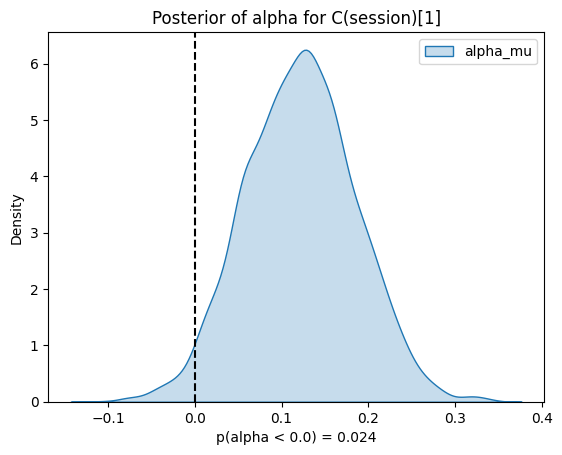

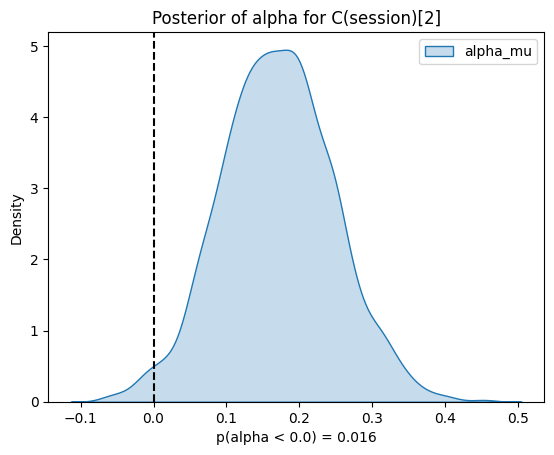

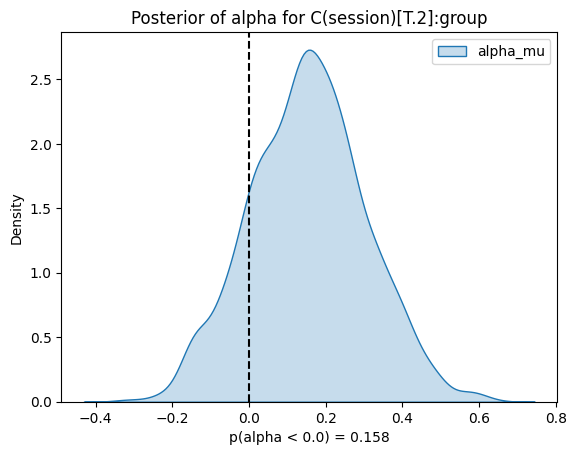

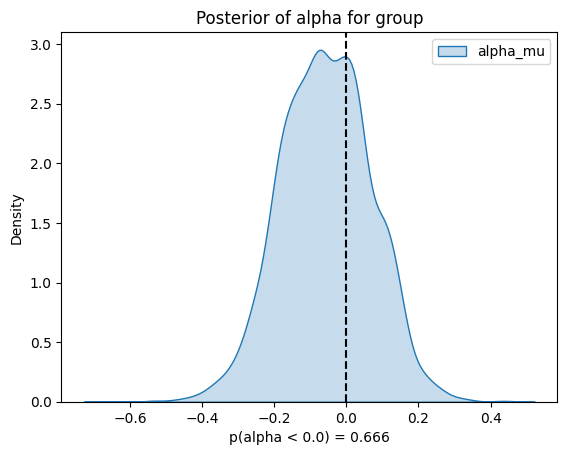

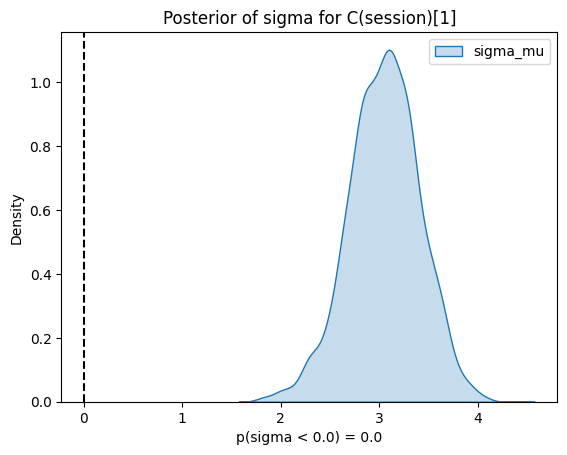

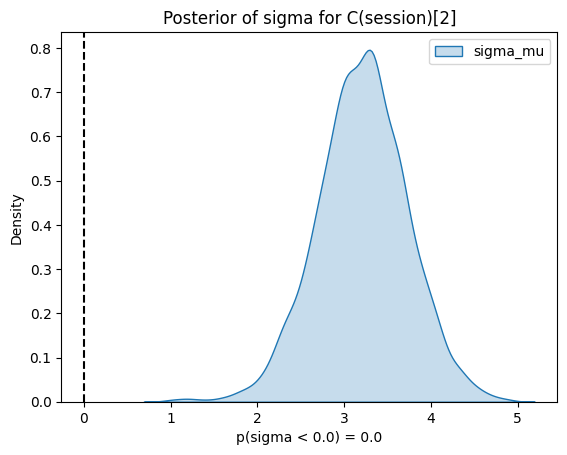

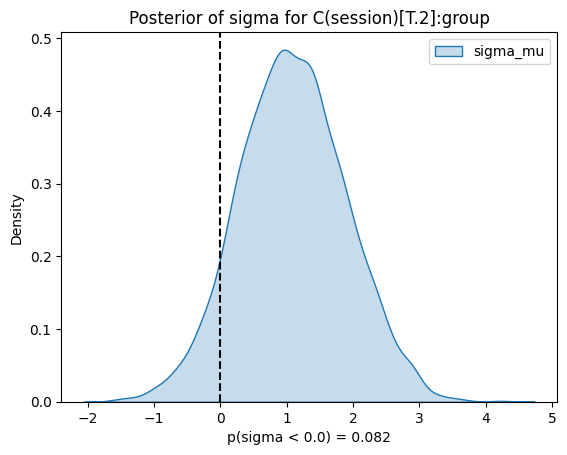

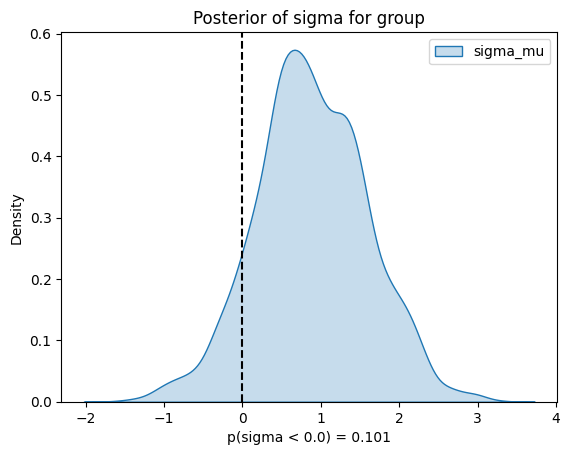

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


for par in model.free_parameters:
    traces = idata.posterior[par+'_mu'].to_dataframe()

    for regressor, t in traces.groupby(par+'_regressors'):
            plt.figure()
            sns.kdeplot(t, fill=True)

            if regressor != 'Intercept':
                plt.axvline(0.0, c='k', ls='--')
                txt = f'p({par} < 0.0) = {np.round((t.values < 0.0).mean(), 3)}'
                plt.xlabel(txt)
            plt.title(f'Posterior of {par} for {regressor}')